# Regresion logistica

### 1. Datos
Usamos HeartDisease como respuesta: 0 = no y 1 = si.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Heart Prediction Quantum Dataset.csv')
print('Filas y columnas:', data.shape)

Filas y columnas: (500, 6)


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            500 non-null    int64
 1   Gender         500 non-null    str  
 2   BloodPressure  500 non-null    str  
 3   Cholesterol    500 non-null    int64
 4   HeartRate      500 non-null    int64
 5   HeartDisease   500 non-null    int64
dtypes: int64(4), str(2)
memory usage: 29.3 KB


In [4]:
data.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


### 2. Revisar datos
Buscamos faltantes, duplicados y errores de formato.

In [5]:
print('Gender:', data['Gender'].unique())
print('Faltantes:')
print(data.isna().sum())
print('Duplicados:', data.duplicated().sum())
print('Presiones con coma:', data['BloodPressure'].str.contains(',').sum())

Gender: <ArrowStringArray>
['Hombre   ',     'Mujer',     'ombre',     'mujer',     'MUjer',     'MUJER',
    'Mujer{',   'Hombre}',    'Hombre']
Length: 9, dtype: str
Faltantes:
Age              0
Gender           0
BloodPressure    0
Cholesterol      0
HeartRate        0
HeartDisease     0
dtype: int64
Duplicados: 0
Presiones con coma: 126


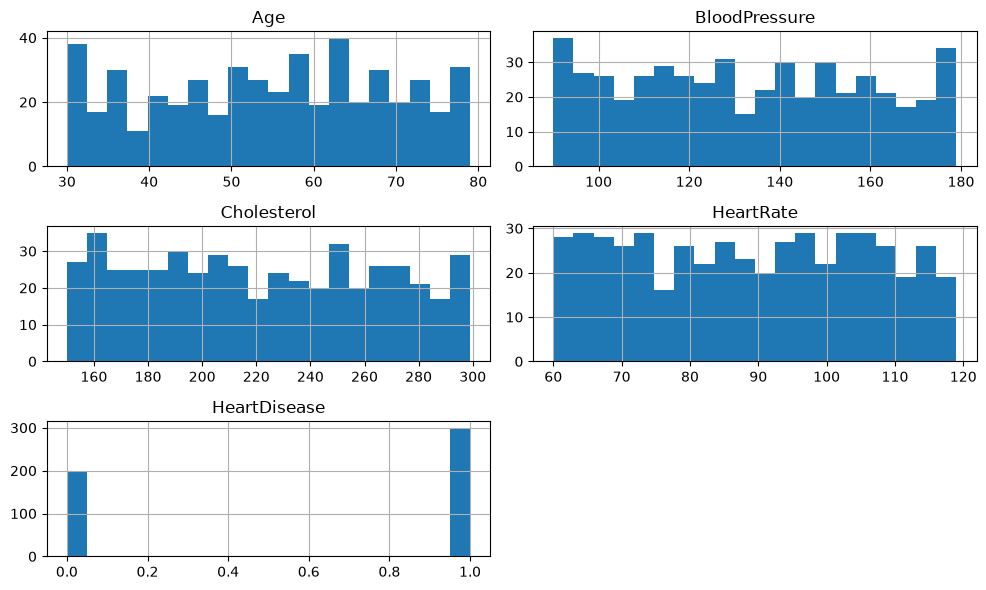

In [6]:
# Copia para graficar antes de limpiar
vista = data.drop(columns='Gender').copy()
vista['BloodPressure'] = vista['BloodPressure'].str.replace(',', '.', regex=False)
vista['BloodPressure'] = vista['BloodPressure'].astype(float)

vista.hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

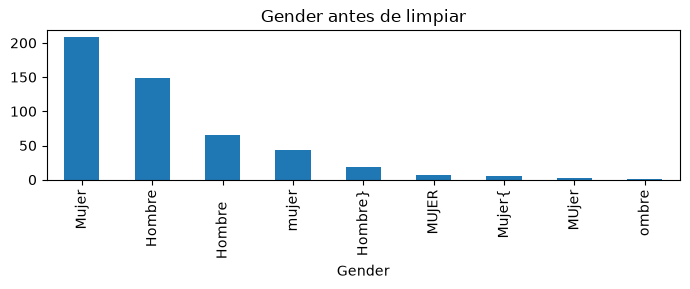

In [7]:
data['Gender'].value_counts().plot.bar(figsize=(7, 3))
plt.title('Gender antes de limpiar')
plt.tight_layout()
plt.show()

### 3. Limpieza
Corregimos presion y pasamos Gender a 0 y 1.

In [8]:
# La presion debe ser numerica para poder usarla en el modelo.
antes = len(data)

data['BloodPressure'] = data['BloodPressure'].str.replace(',', '.', regex=False)
data['BloodPressure'] = data['BloodPressure'].astype(float)

In [9]:
# Juntamos las distintas formas de escribir hombre y mujer.
data['Gender'] = data['Gender'].str.lower()
print('Tras lower:', data['Gender'].unique())

data['Gender'] = data['Gender'].str.rstrip(' {}')
print('Tras rstrip:', data['Gender'].unique())

data['Gender'] = data['Gender'].replace({'ombre': 'hombre'})
data['Gender'] = data['Gender'].map({'hombre': 1, 'mujer': 0})

Tras lower: <ArrowStringArray>
['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre']
Length: 6, dtype: str
Tras rstrip: <ArrowStringArray>
['hombre', 'mujer', 'ombre']
Length: 3, dtype: str


In [10]:
data = data.drop_duplicates().dropna()
data['Gender'] = data['Gender'].astype(int)

print('Filas antes:', antes)
print('Filas despues:', len(data))
print('Gender final:', data['Gender'].unique())
data.dtypes

Filas antes: 500
Filas despues: 500
Gender final: [1 0]


Age                int64
Gender             int64
BloodPressure    float64
Cholesterol        int64
HeartRate          int64
HeartDisease       int64
dtype: object

### 4. EDA
Revisamos distribuciones, estadisticas y atipicos.

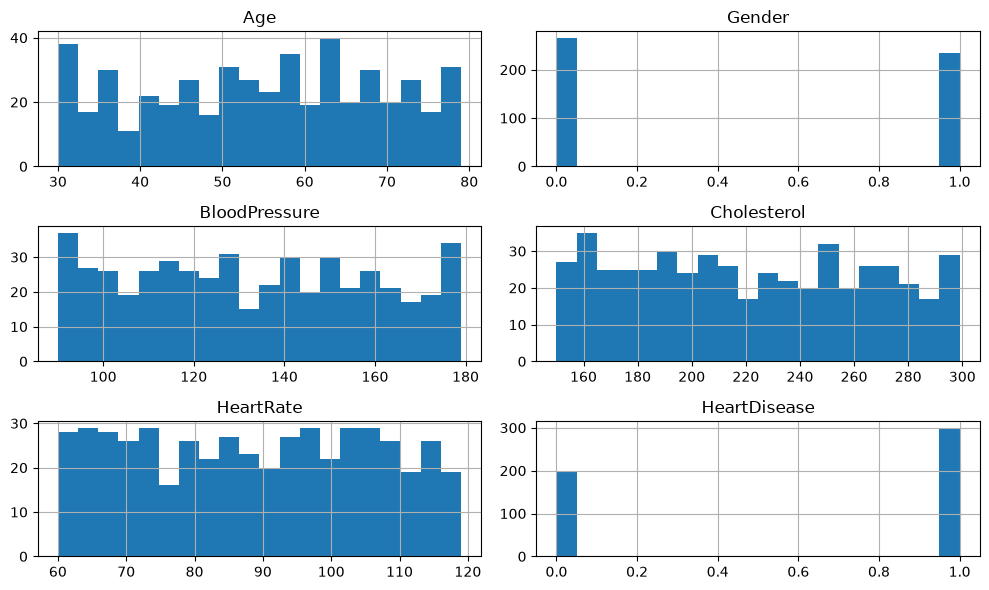

In [11]:
data.hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [12]:
numericas = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']

estadisticas = pd.DataFrame()
estadisticas['mean'] = data[numericas].mean()
estadisticas['median'] = data[numericas].median()
estadisticas['std'] = data[numericas].std()
estadisticas['min'] = data[numericas].min()
estadisticas['max'] = data[numericas].max()

In [13]:
# Con este criterio no aparecen atipicos en las variables numericas.
q1 = data[numericas].quantile(0.25)
q3 = data[numericas].quantile(0.75)
iqr = q3 - q1

atipicos = ((data[numericas] < q1 - 1.5 * iqr) |
            (data[numericas] > q3 + 1.5 * iqr)).sum()
estadisticas['atípicos'] = atipicos
estadisticas.round(2)

,mean,median,std,min,max,atípicos
Age,54.86,55.0,14.32,30.0,79.0,0
BloodPressure,132.87,132.0,26.42,90.0,179.0,0
Cholesterol,221.50,221.0,43.86,150.0,299.0,0
HeartRate,88.77,89.0,17.42,60.0,119.0,0


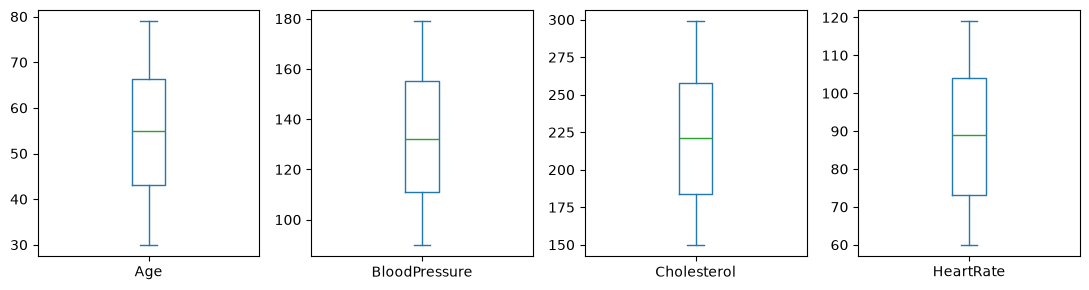

In [14]:
data[numericas].plot.box(subplots=True, layout=(1, 4), figsize=(11, 3), sharey=False)
plt.tight_layout()
plt.show()

In [15]:
# 0 = mujer; 1 = hombre
frecuencia = data['Gender'].value_counts().sort_index()
print('Valores unicos:', sorted(data['Gender'].unique()))

tabla = pd.DataFrame()
tabla['Frecuencia'] = frecuencia
tabla['%'] = np.round(100 * frecuencia / len(data), 1)
tabla

Valores unicos: [np.int64(0), np.int64(1)]


,Frecuencia,%
Gender,,
0,266,53.2
1,234,46.8


In [16]:
# 0 = sin enfermedad; 1 = con enfermedad
frecuencia = data['HeartDisease'].value_counts().sort_index()
print('Valores unicos:', sorted(data['HeartDisease'].unique()))

tabla = pd.DataFrame()
tabla['Frecuencia'] = frecuencia
tabla['%'] = np.round(100 * frecuencia / len(data), 1)
tabla

Valores unicos: [np.int64(0), np.int64(1)]


,Frecuencia,%
HeartDisease,,
0,200,40.0
1,300,60.0


In [17]:
# Aqui vemos cuantos casos hay de cada respuesta por sexo.
pd.crosstab(data['Gender'], data['HeartDisease'], margins=True)

HeartDisease,0,1,All
Gender,,,
0,105,161,266
1,95,139,234
All,200,300,500


In [18]:
# Porcentaje de cada diagnostico dentro de cada sexo
(pd.crosstab(data['Gender'], data['HeartDisease'], normalize='index') * 100).round(1)

HeartDisease,0,1
Gender,,
0,39.5,60.5
1,40.6,59.4


### Conclusion del EDA
Quedaron 500 datos, sin faltantes ni atipicos con el criterio IQR. Hay 300 casos con enfermedad y 200 sin enfermedad.

### 5. Regresion logistica multiple
Usamos Age, Gender, BloodPressure, Cholesterol y HeartRate para predecir HeartDisease.

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
# X lleva las cinco variables; y es lo que queremos predecir.
X = data.drop(columns=['HeartDisease'])
y = data['HeartDisease']
X.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate
0,68,1,105.0,191,107
1,58,0,97.0,249,89
2,44,0,93.0,190,82
3,72,1,93.0,183,101
4,37,0,145.0,166,103


In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [22]:
# Cada coeficiente corresponde a una X, manteniendo las demas fijas.
b0 = lr.intercept_[0]

print('b0:', round(b0, 6))

coeficientes = pd.DataFrame()
coeficientes['Variable'] = X.columns
coeficientes['Coeficiente'] = lr.coef_[0]
coeficientes

b0: 7.069513


,Variable,Coeficiente
0,Age,0.050365
1,Gender,-0.028631
2,BloodPressure,-0.015858
3,Cholesterol,-0.025109
4,HeartRate,-0.017874


### 6. Probabilidades y threshold
Con C = 1 probamos los thresholds 0.3, 0.5 y 0.8.

In [23]:
# Obtenemos la probabilidad de cada clase, no solo 0 o 1.
probabilidades = lr.predict_proba(X)
print('Orden de las clases:', lr.classes_)
probabilidades[:5]

Orden de las clases: [0 1]


array([[0.1098549 , 0.8901451 ],
       [0.35218225, 0.64781775],
       [0.17159702, 0.82840298],
       [0.05775277, 0.94224723],
       [0.34876869, 0.65123131]])

In [24]:
# La segunda columna corresponde a la clase 1
p = probabilidades[:, 1]
p[:5]

array([0.8901451 , 0.64781775, 0.82840298, 0.94224723, 0.65123131])

#### TP, TN, FP y FN
Comparamos lo que predice el modelo con el valor real.

#### Threshold = 0.3

In [25]:
# Si la probabilidad llega al threshold, lo tomamos como positivo.
threshold = 0.3
pred = (p >= threshold).astype(int)
pred[:5]

array([1, 1, 1, 1, 1])

In [26]:
# Real 1 y predicho 1: positivo correcto
TP = np.sum((y == 1) & (pred == 1))
# Real 0 y predicho 0: negativo correcto
TN = np.sum((y == 0) & (pred == 0))
# Real 0, pero predicho 1: falso positivo
FP = np.sum((y == 0) & (pred == 1))
# Real 1, pero predicho 0: falso negativo
FN = np.sum((y == 1) & (pred == 0))

In [27]:
print('TP:', TP)
print('TN:', TN)
print('FP:', FP)
print('FN:', FN)
print('Total:', TP + TN + FP + FN)

conteos_03 = [threshold, TP, TN, FP, FN]

TP: 281
TN: 73
FP: 127
FN: 19
Total: 500


#### Threshold = 0.5

In [30]:
threshold = 0.5
pred = (p >= threshold).astype(int)
pred[:5]

array([1, 1, 1, 1, 1])

In [31]:
# Real 1 y predicho 1: positivo correcto
TP = np.sum((y == 1) & (pred == 1))
# Real 0 y predicho 0: negativo correcto
TN = np.sum((y == 0) & (pred == 0))
# Real 0, pero predicho 1: falso positivo
FP = np.sum((y == 0) & (pred == 1))
# Real 1, pero predicho 0: falso negativo
FN = np.sum((y == 1) & (pred == 0))

In [32]:
print('TP:', TP)
print('TN:', TN)
print('FP:', FP)
print('FN:', FN)
print('Total:', TP + TN + FP + FN)

conteos_05 = [threshold, TP, TN, FP, FN]

TP: 238
TN: 127
FP: 73
FN: 62
Total: 500


#### Threshold = 0.8

In [35]:
threshold = 0.8
pred = (p >= threshold).astype(int)
pred[:5]

array([1, 0, 1, 1, 0])

In [36]:
# Real 1 y predicho 1: positivo correcto
TP = np.sum((y == 1) & (pred == 1))
# Real 0 y predicho 0: negativo correcto
TN = np.sum((y == 0) & (pred == 0))
# Real 0, pero predicho 1: falso positivo
FP = np.sum((y == 0) & (pred == 1))
# Real 1, pero predicho 0: falso negativo
FN = np.sum((y == 1) & (pred == 0))

In [37]:
print('TP:', TP)
print('TN:', TN)
print('FP:', FP)
print('FN:', FN)
print('Total:', TP + TN + FP + FN)

conteos_08 = [threshold, TP, TN, FP, FN]

TP: 134
TN: 184
FP: 16
FN: 166
Total: 500


#### Comparacion de thresholds
Los conteos de cada fila deben sumar 500.

In [40]:
comparacion_thresholds = pd.DataFrame(
    [conteos_03, conteos_05, conteos_08],
    columns=['Threshold', 'TP', 'TN', 'FP', 'FN']
)
comparacion_thresholds

,Threshold,TP,TN,FP,FN
0,0.3,281,73,127,19
1,0.5,238,127,73,62
2,0.8,134,184,16,166


#### Conclusion de los thresholds
Con 0.3 detectamos mas positivos, pero tambien tenemos mas falsos positivos. Con 0.5 quedan menos falsos positivos, aunque se nos pasan mas casos reales. Con 0.8 somos mas estrictos para predecir 1: los falsos positivos bajan a 16, pero los falsos negativos suben a 166. Entiendo que subir el threshold cambia el tipo de error que cometemos, no significa que todo mejore. Esto se observa en los mismos datos usados para ajustar.

### 7. Comparacion de C
Probamos los tres valores de C de Lab - R3.

In [43]:
# Un C menor aplica mas penalizacion a los coeficientes.
resultados = []

for c in [0.000001, 0.1, 1000000]:
    lr = LogisticRegression(C=c, max_iter=1000)
    lr.fit(X, y)
    resultados.append([c, lr.intercept_[0]] + list(lr.coef_[0]))

pd.DataFrame(resultados, columns=['C', 'b0'] + list(X.columns))

,C,b0,Age,Gender,BloodPressure,Cholesterol,HeartRate
0,0.000001,1.311745,0.000881,-0.000001,-0.000718,-0.003698,-0.000421
1,0.100000,7.063223,0.050335,-0.020409,-0.015845,-0.025107,-0.017855
2,1000000.000000,7.070495,0.050369,-0.029965,-0.015860,-0.025109,-0.017877


#### Conclusion de C
Con C = 0.000001 los coeficientes quedan mas cerca de cero porque la penalizacion es mayor. Al subir a 0.1, las variables tienen mas peso en el modelo. Con C = 1000000 la penalizacion es muy pequeña y casi todos los coeficientes cambian poco respecto a 0.1, aunque Gender cambia mas en proporcion. Entiendo que C controla cuanto se limitan los coeficientes; un C mas grande no significa por si solo que el modelo prediga mejor.